# Breast Cancer CAD System — Master Notebook

End-to-end pipeline: **Preprocessing -> YOLO26n (detection) -> U-Net (segmentation) -> ResNet50 (classification)**.

Every cell below calls into the reusable modules under `preprocessing/`, `yolo/`, `unet/`, `resnet/`, `inference/` — no pipeline logic is duplicated here.

**Important:** the training cells (Stage 2/3/4) are provided fully ready-to-run but are **not meant to be executed automatically** (e.g. via "Run All") — training each stage takes substantial time and should be run deliberately, one stage at a time, on your own hardware/schedule.

In [7]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
# config.yaml paths (dataset/, checkpoints/, results/, ...) are relative to the repo root,
# so run the kernel from there rather than from notebooks/.
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.config import load_config
from utils.seed import set_seed, get_device

config = load_config(str(REPO_ROOT / "config.yaml"))
# Uncomment to smoke-test the whole pipeline on a tiny subset before a real run:
# config = load_config(str(REPO_ROOT / "config.yaml"), overrides=str(REPO_ROOT / "configs/quick_run.yaml"))

set_seed(config["seed"], config["deterministic"])
device = get_device(config.get("device"))
print(f"Device: {device}")
print(f"Repo root: {REPO_ROOT}")


Device: mps
Repo root: /Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection


## Stage 1 — Preprocessing & Augmentation

Validates every image/mask pair, builds a stratified 70/15/15 split (content-duplicate-aware — see the
`duplicate_image_cross_class` check in `preprocessing/validation.py`), derives per-lesion YOLO bounding
boxes from the masks, and renders sanity-check visualizations. No model training happens in this stage —
safe to re-run any time.

2026-10-05 11:13:04 | INFO     | preprocessing | Building manifest from raw BUSI_Jpeg directories...
2026-10-05 11:13:04 | INFO     | preprocessing | Found 647 images.
2026-10-05 11:13:04 | INFO     | preprocessing | Validating dataset (pairing, corruption, duplicates, dimensions, masks)...
2026-10-05 11:13:04 | INFO     | preprocessing | 0 critical issue(s), 1 warning(s).
2026-10-05 11:13:04 | WARNING  | preprocessing | [duplicate_image_cross_class] malignant (145): identical to benign (433) (benign)
2026-10-05 11:13:04 | INFO     | preprocessing | Splitting dataset (stratified 70/15/15, seed=42)...
2026-10-05 11:13:05 | INFO     | preprocessing | Split sizes: {'train': 452, 'val': 98, 'test': 97}
2026-10-05 11:13:05 | INFO     | preprocessing | Split class counts: {'train': {'benign': 306, 'malignant': 146}, 'val': {'benign': 65, 'malignant': 33}, 'test': {'benign': 66, 'malignant': 31}}
2026-10-05 11:13:05 | INFO     | preprocessing | Building per-lesion manifests...
2026-10-05 11:1

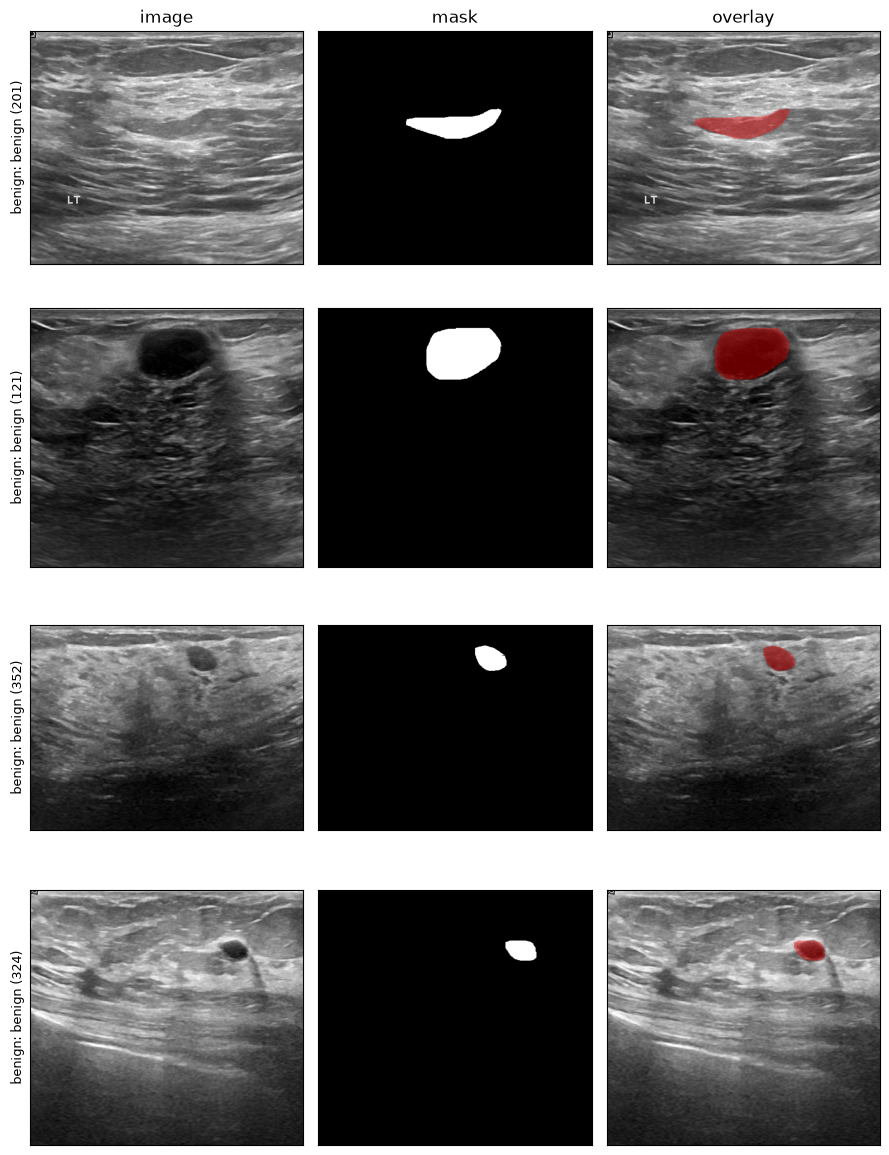

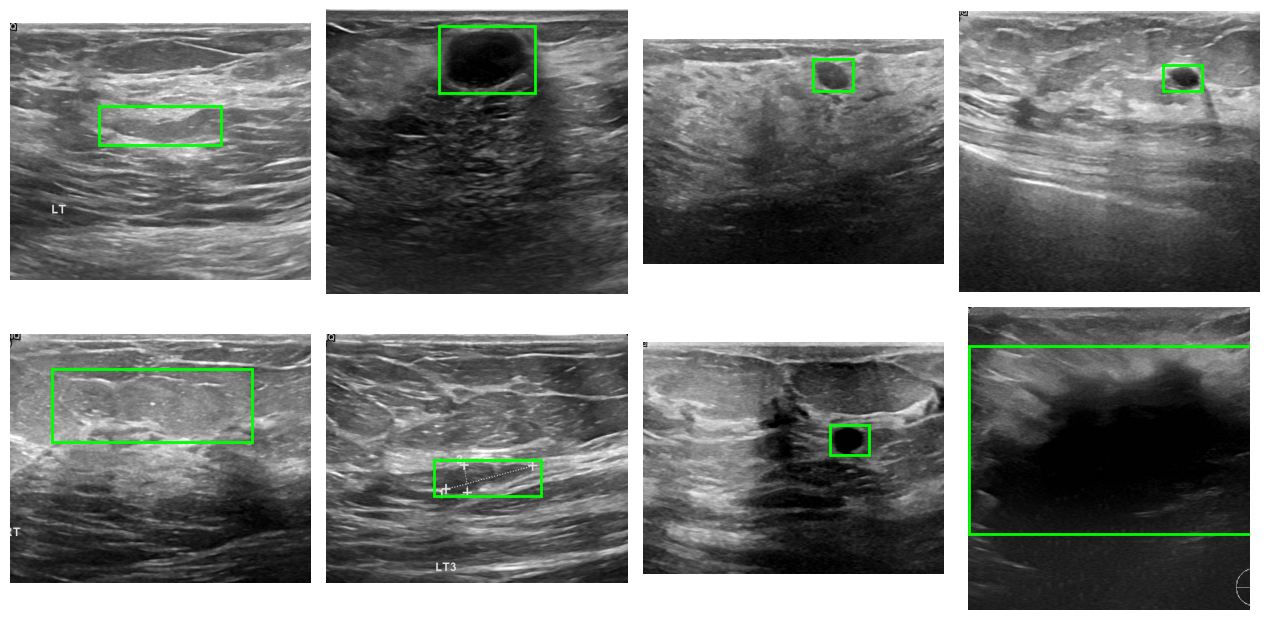

In [8]:
from preprocessing.pipeline import run_stage1

stage1_result = run_stage1(config)
print(stage1_result["report"])


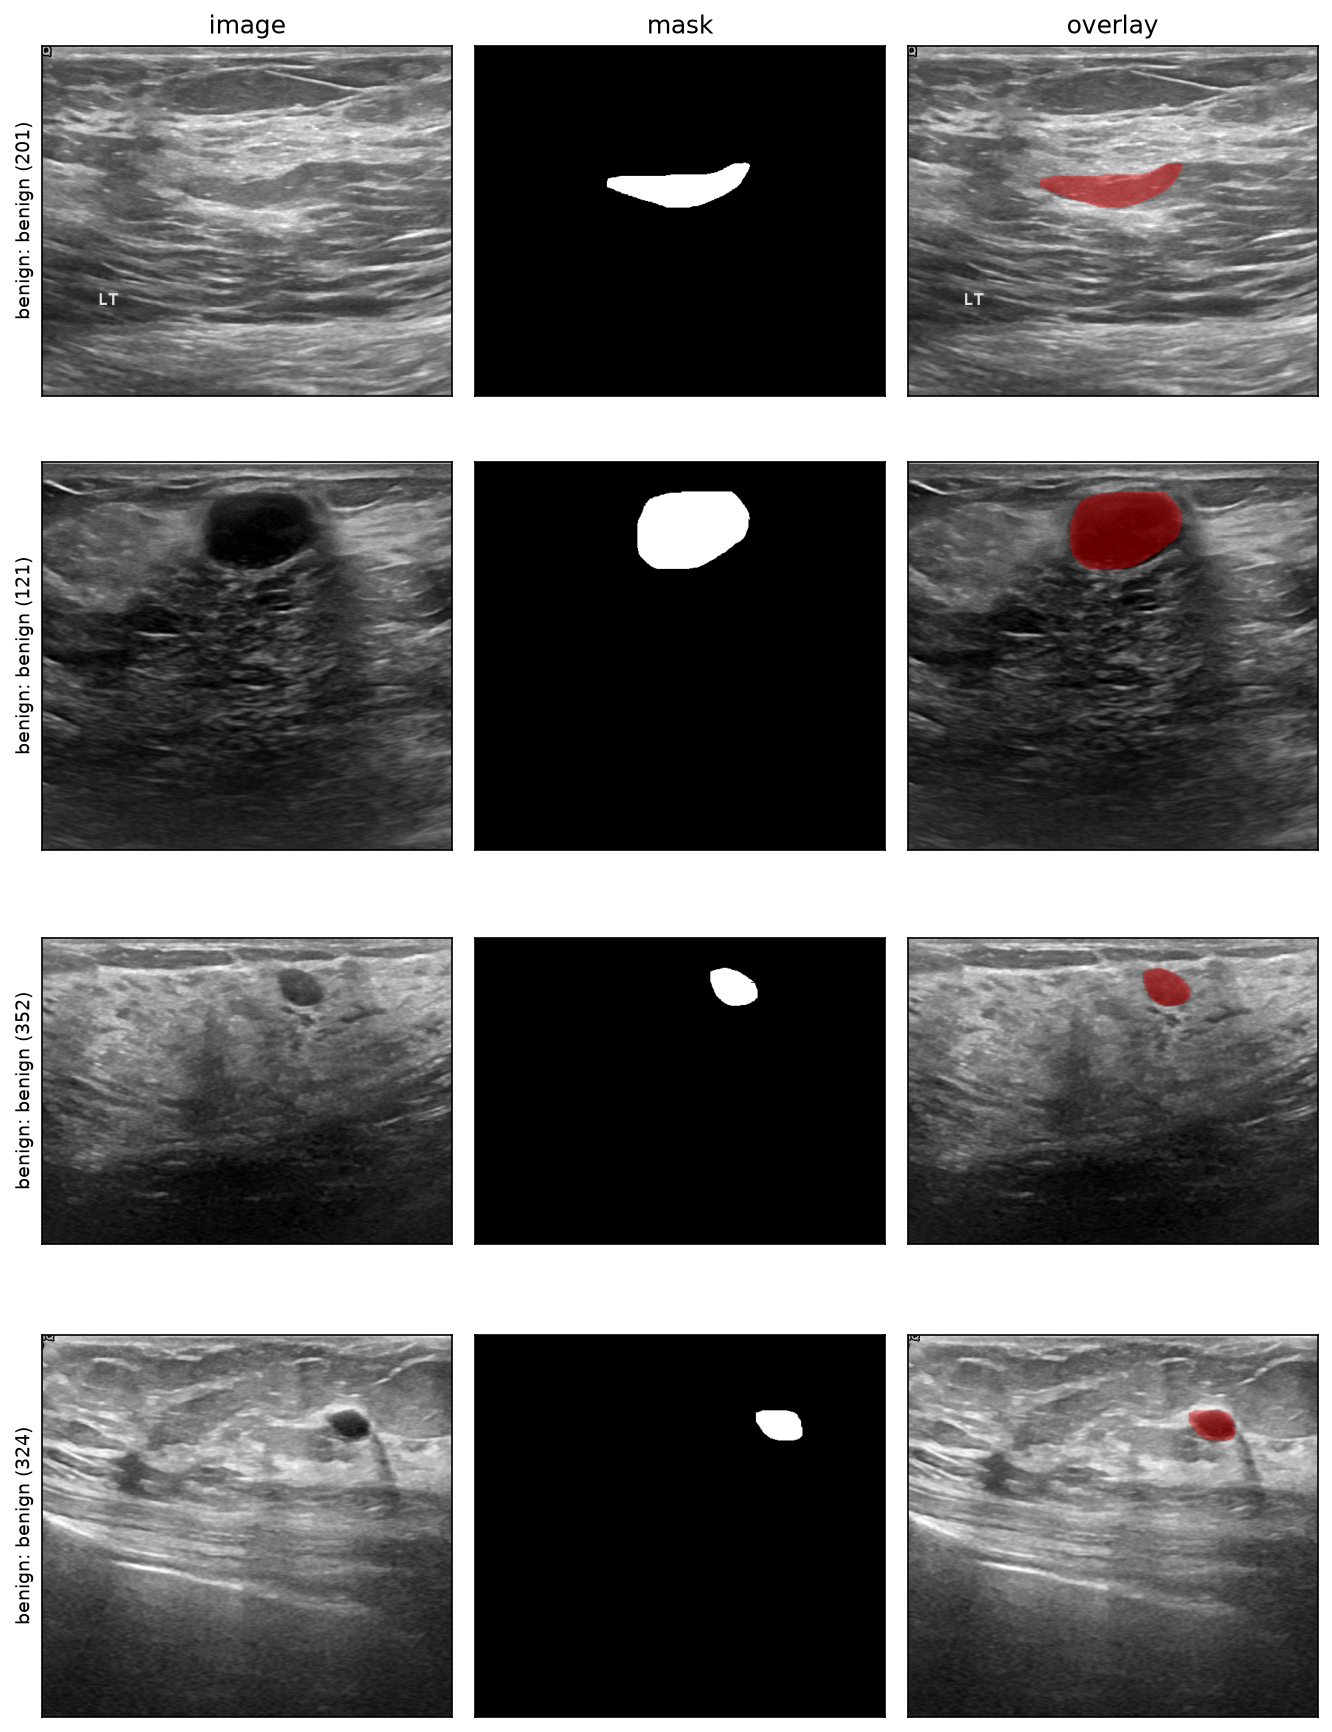

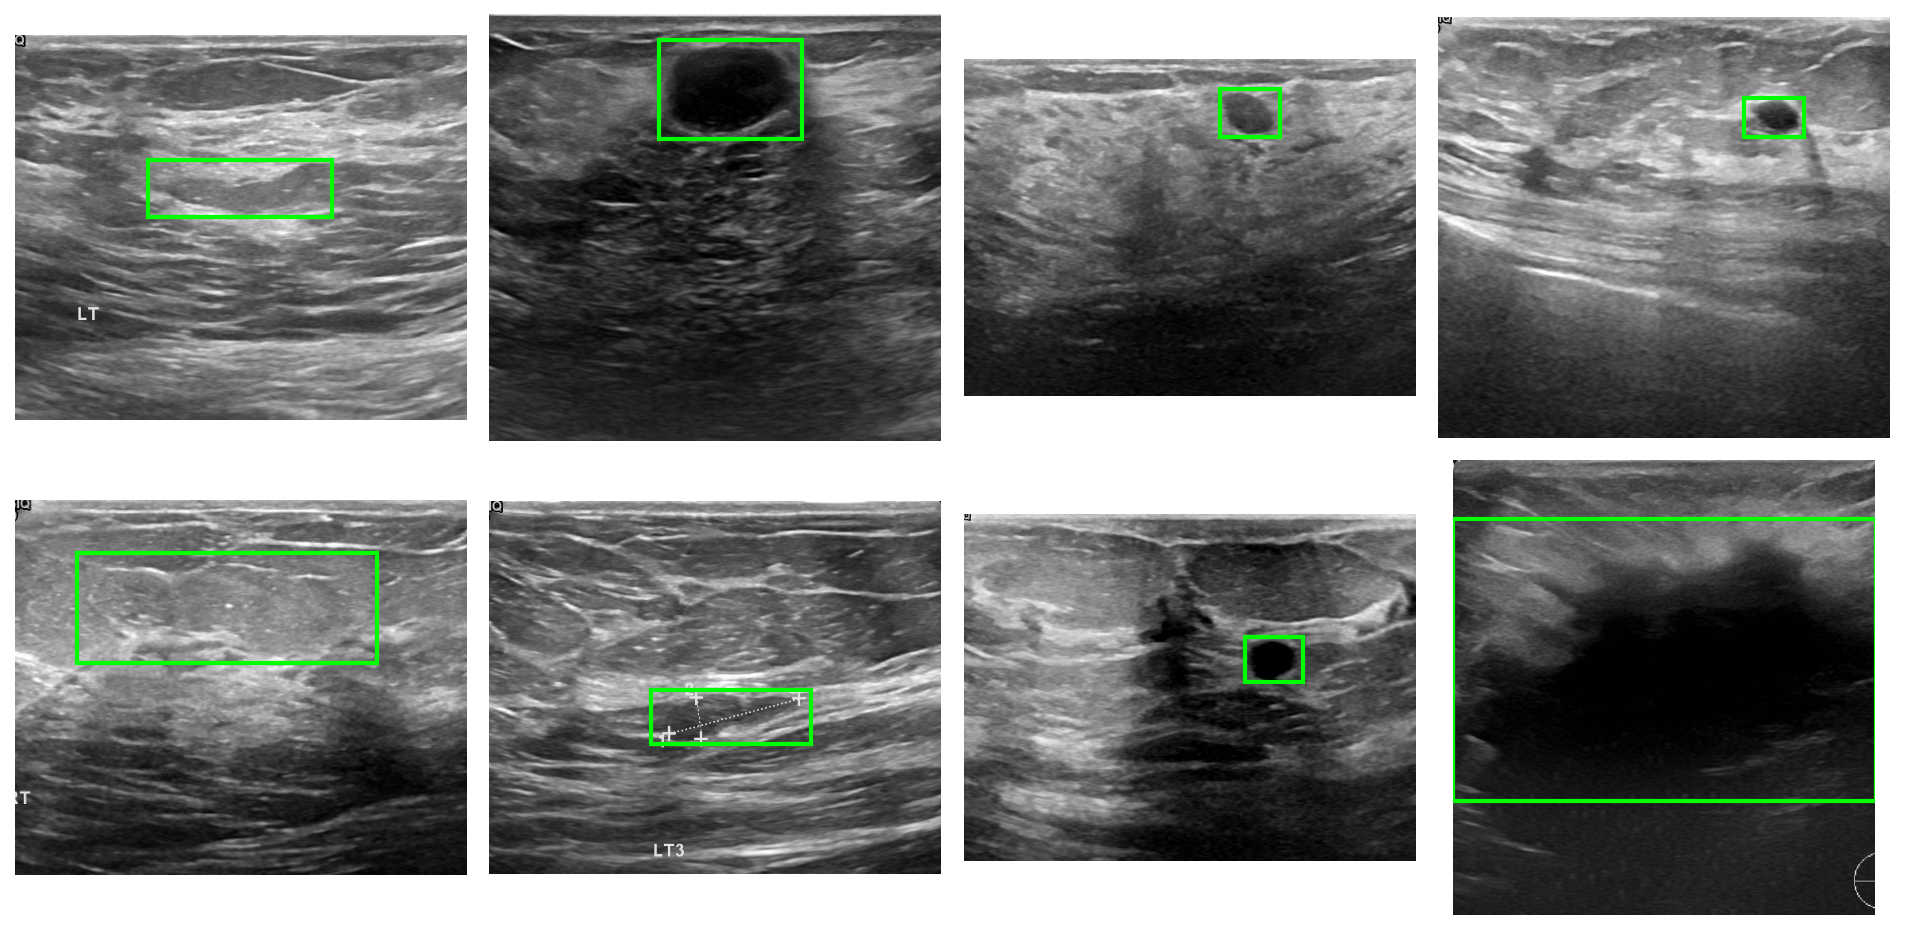

In [9]:
from IPython.display import Image as IPImage, display

results_dir = REPO_ROOT / config["paths"]["results"] / "preprocessing"
display(IPImage(filename=str(results_dir / "mask_sanity_check.png")))
display(IPImage(filename=str(results_dir / "bbox_overlay_check.png")))


YOLO-stage augmentations (full safe + cautious set):
U-Net-stage augmentations (safe + cautious + tiny elastic):
ResNet-stage augmentations (conservative safe set only):


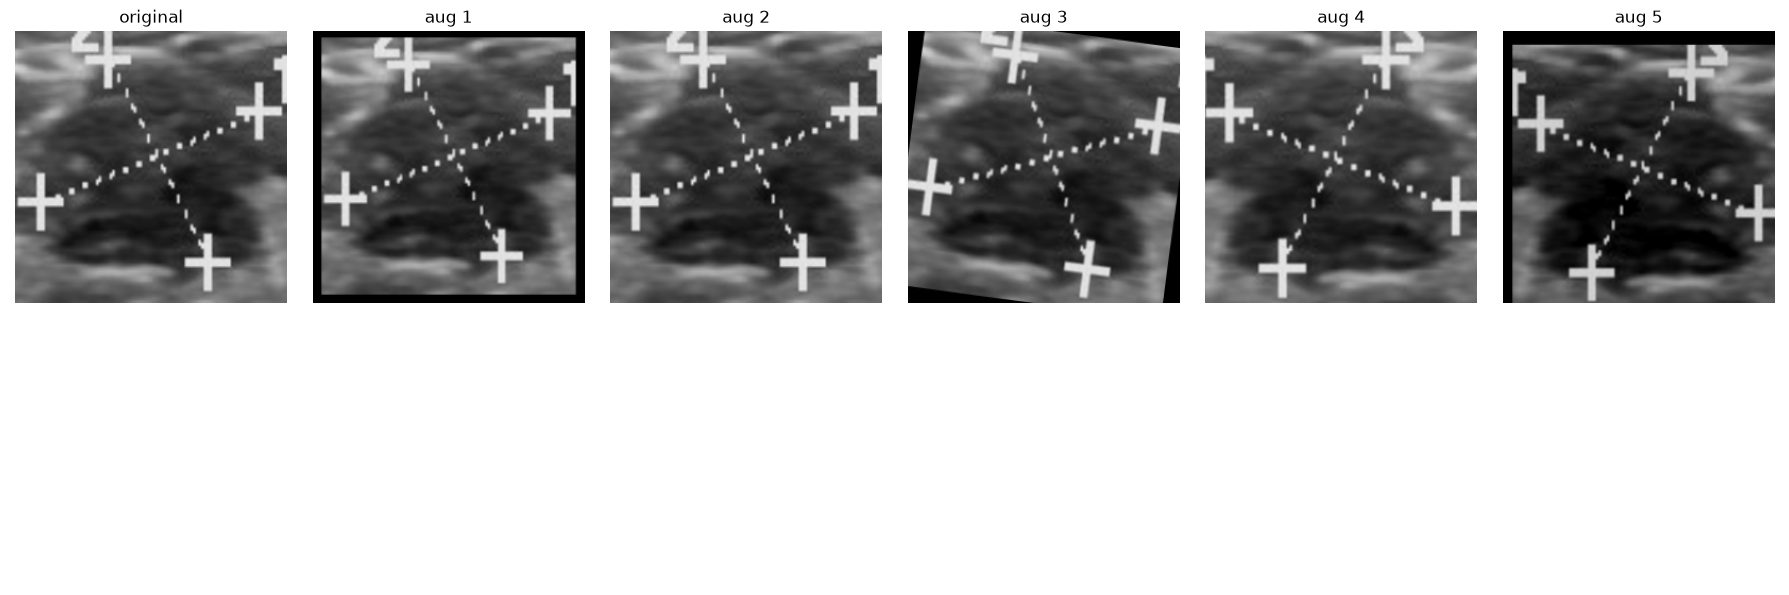

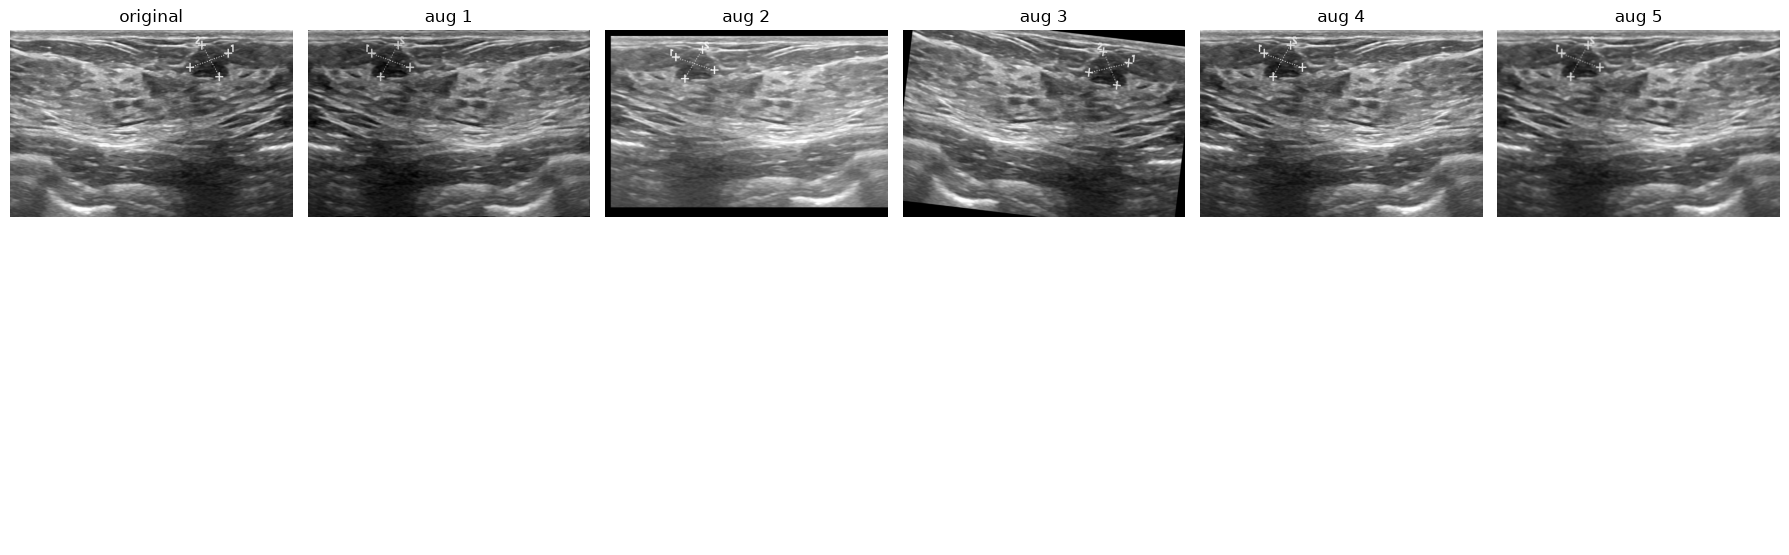

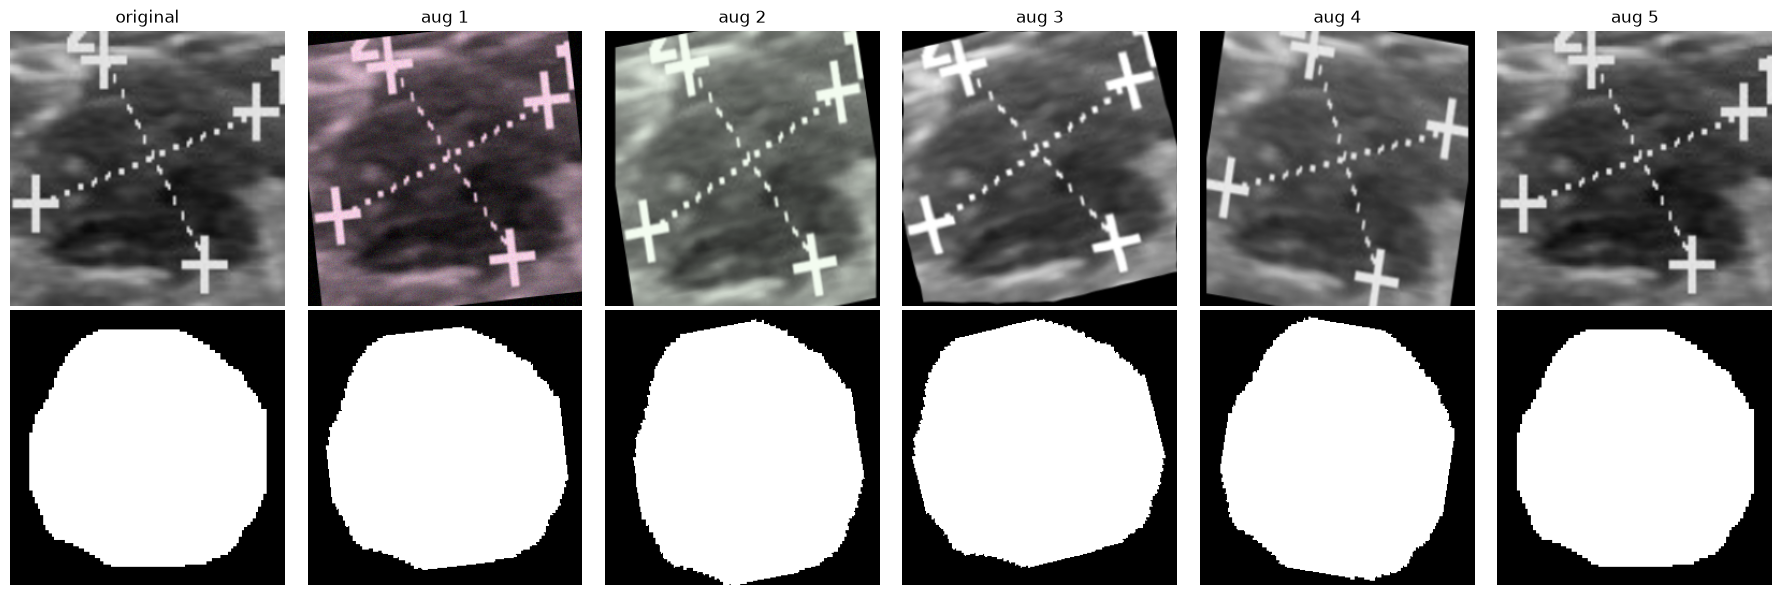

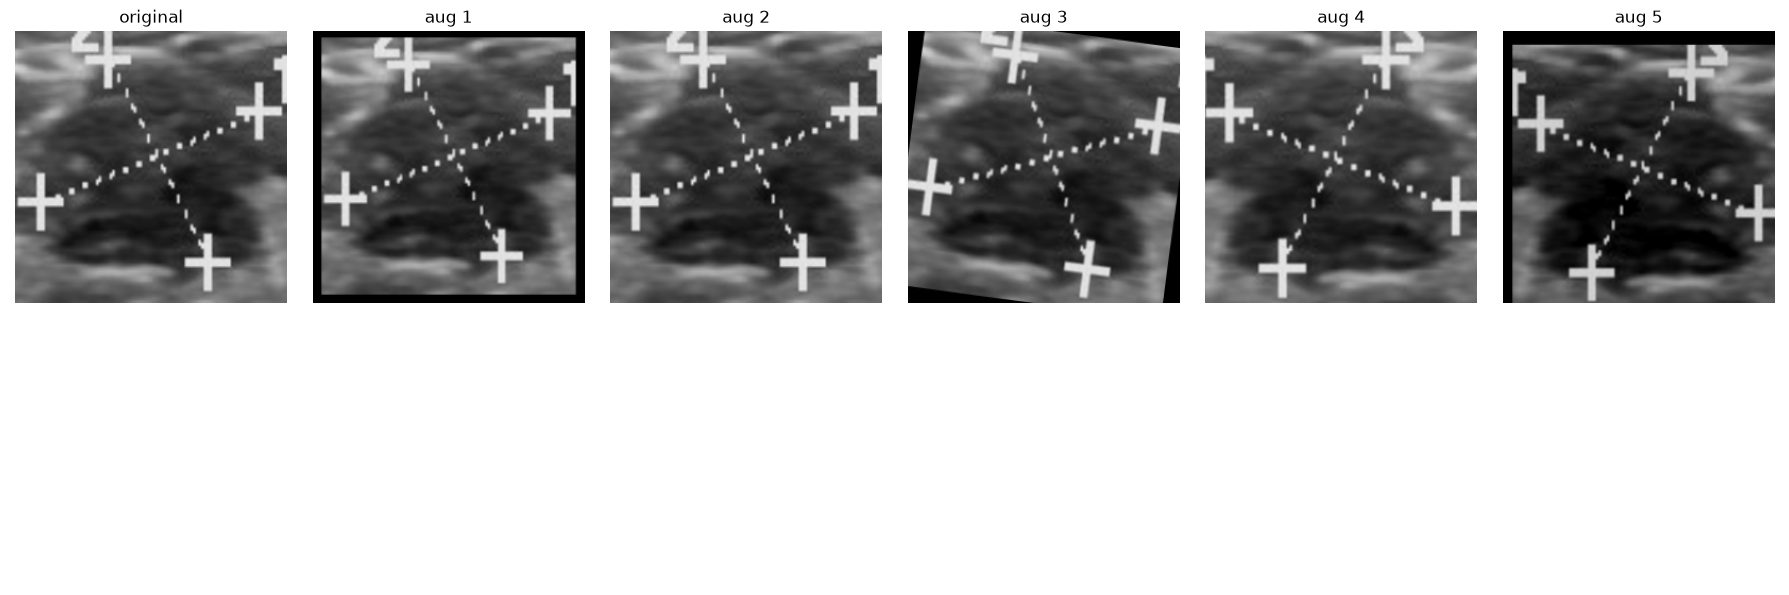

In [10]:
import random

import albumentations as A

from dataset.lesion_manifest import load_lesion_manifest
from preprocessing.mask_to_yolo import component_mask
from preprocessing.normalization import load_image_rgb
from preprocessing.roi_utils import crop_roi_pair
from preprocessing.augmentation import (
    build_yolo_augmentations,
    build_unet_augmentations,
    build_resnet_augmentations,
    visualize_augmentations,
)

train_lesions = load_lesion_manifest(REPO_ROOT / config["paths"]["splits_dir"] / "train_lesions.json")
sample_row = random.Random(config["seed"]).choice(train_lesions)
sample_image = load_image_rgb(sample_row["image_path"])
sample_mask = component_mask(sample_row["source_mask_path"], sample_row["component_label"])
roi_size = tuple(config["preprocessing"]["roi_size"])
roi_crop, mask_crop, _ = crop_roi_pair(
    sample_image, sample_mask, tuple(sample_row["bbox"]), pad_ratio=0.0, target_size=roi_size
)

# The YOLO pipeline is bbox-aware (BBoxSafeRandomCrop needs bboxes at call time),
# so the preview keeps bbox_params and feeds the sample lesion's pixel bbox through.
# Resize is dropped so the preview stays at the original resolution.
yolo_transforms = build_yolo_augmentations(config["yolo"]["imgsz"]).transforms
yolo_compose = A.Compose(
    [t for t in yolo_transforms if not isinstance(t, A.Resize)],
    bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"], min_visibility=0.3),
)


def yolo_preview(**kwargs):
    return yolo_compose(**kwargs, bboxes=[sample_row["bbox"]], class_labels=[0])


print("YOLO-stage augmentations (full safe + cautious set):")
visualize_augmentations(sample_image, yolo_preview, n_samples=5)

print("U-Net-stage augmentations (safe + cautious + tiny elastic):")
visualize_augmentations(roi_crop, build_unet_augmentations(roi_size), n_samples=5, mask=mask_crop)

print("ResNet-stage augmentations (conservative safe set only):")
visualize_augmentations(roi_crop, build_resnet_augmentations(roi_size), n_samples=5)


## Stage 2 — YOLO26n Detection

Builds the Ultralytics-format dataset (images + YOLO labels + `data.yaml`) from the Stage 1 split, then
trains YOLO26n to localize the tumor. The dataset-build cell is safe to run any time; **the training
cell trains a real model and should be run deliberately, not as part of "Run All".**

In [11]:
from dataset.splits import load_split
from yolo.dataset_builder import build_yolo_dataset

splits = {name: load_split(REPO_ROOT / config["paths"]["splits_dir"], name) for name in ("train", "val", "test")}
data_yaml = build_yolo_dataset(
    splits,
    REPO_ROOT / config["paths"]["yolo_dataset_dir"],
    min_area_px=config["preprocessing"]["min_mask_area_px"],
    bbox_pad_ratio=config["preprocessing"]["bbox_pad_ratio"],
)
print(f"YOLO dataset ready at {data_yaml}")


2026-10-05 11:13:08 | INFO     | yolo_dataset_builder | Built YOLO train split: 452 images -> /Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/dataset/yolo_dataset/images/train
2026-10-05 11:13:08 | INFO     | yolo_dataset_builder | Built YOLO val split: 98 images -> /Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/dataset/yolo_dataset/images/val
2026-10-05 11:13:08 | INFO     | yolo_dataset_builder | Built YOLO test split: 97 images -> /Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/dataset/yolo_dataset/images/test
2026-10-05 11:13:08 | INFO     | yolo_dataset_builder | Wrote /Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/dataset/yolo_dataset/data.yaml
YOLO dataset ready at /Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/dataset/yolo_dataset/data.yaml


In [12]:
# TRAINING CELL — trains a real model. Run manually and deliberately, not via "Run All".
from yolo.train import train_yolo

train_yolo(config, data_yaml)


2026-10-05 11:13:08 | INFO     | yolo_train | Training YOLO26n on device=mps, data=/Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/dataset/yolo_dataset/data.yaml
New https://pypi.org/project/ultralytics/8.4.173 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.12.1 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/dataset/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, 

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=

In [14]:
# Evaluation — run after the training cell above has produced a checkpoint.
from yolo.evaluate import evaluate_yolo, compute_mean_iou

yolo_weights = REPO_ROOT / config["yolo"]["project"] / config["yolo"]["name"] / "weights" / "best.pt"
yolo_metrics = evaluate_yolo(yolo_weights, data_yaml, imgsz=config["yolo"]["imgsz"])

test_lesions = load_lesion_manifest(REPO_ROOT / config["paths"]["splits_dir"] / "test_lesions.json")
iou_metrics = compute_mean_iou(yolo_weights, test_lesions, imgsz=config["yolo"]["imgsz"])
print(yolo_metrics, iou_metrics)


Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.12.1 CPU (Apple M4)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6538.3±2373.7 MB/s, size: 368.2 KB)
val: Scanning /Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/dataset/yolo_dataset/labels/test.cache... 97 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 97/97 50.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.5s/it 10.5s2.1s
                   all         97        100      0.884       0.77      0.734      0.545
Speed: 0.3ms preprocess, 102.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /Users/mulatyazewchekol/Documents/My_Projects/Signal_Imaging_Acquisition_Modelling_Healthcare/runs/detect/results/yolo/eval
2026-10-05 13:33:05 | INFO     | yolo_evaluate | YOLO test-split metrics: {'precision': 0.88386167008

## Stage 3 — U-Net Segmentation

Trains a U-Net (default: ResNet34 encoder, ImageNet-pretrained) on ROI crops derived from the
ground-truth lesion boxes. To compare architectures, reload `config` with one of the
`configs/unet_*.yaml` overrides (attention gates, EfficientNet-B0, U-Net++) before running the
training cell. **Trains a real model — run manually, not via "Run All".**

2026-10-05 13:33:12 | INFO     | unet_train | Training unet (encoder=resnet34) on device=mps


/Users/mulatyazewchekol/Documents/My_Projects/Healthcare_Projects/Breast_Cancer_Detection/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


2026-10-05 13:34:11 | INFO     | unet_train | epoch 1/100 | train_loss=0.3779 train_dice=0.8285 | val_loss=0.2757 val_dice=0.8948
2026-10-05 13:34:12 | INFO     | unet_train | New best val dice 0.8948 -> saved checkpoints/unet/best_unet.pth
2026-10-05 13:35:07 | INFO     | unet_train | epoch 2/100 | train_loss=0.2433 train_dice=0.9088 | val_loss=0.2076 val_dice=0.9171
2026-10-05 13:35:08 | INFO     | unet_train | New best val dice 0.9171 -> saved checkpoints/unet/best_unet.pth
2026-10-05 13:36:02 | INFO     | unet_train | epoch 3/100 | train_loss=0.2065 train_dice=0.9195 | val_loss=0.1917 val_dice=0.9197
2026-10-05 13:36:03 | INFO     | unet_train | New best val dice 0.9197 -> saved checkpoints/unet/best_unet.pth
2026-10-05 13:36:59 | INFO     | unet_train | epoch 4/100 | train_loss=0.1870 train_dice=0.9231 | val_loss=0.1758 val_dice=0.9245
2026-10-05 13:37:00 | INFO     | unet_train | New best val dice 0.9245 -> saved checkpoints/unet/best_unet.pth
2026-10-05 13:37:56 | INFO     | une

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05,

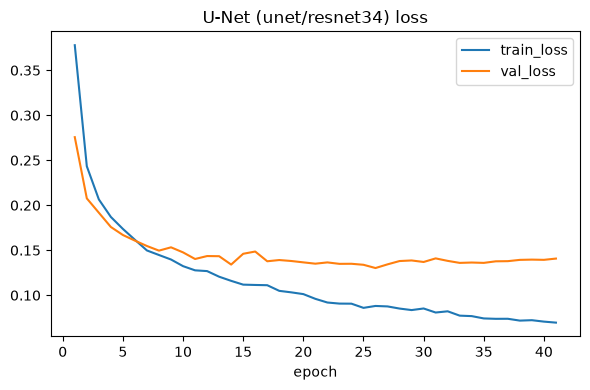

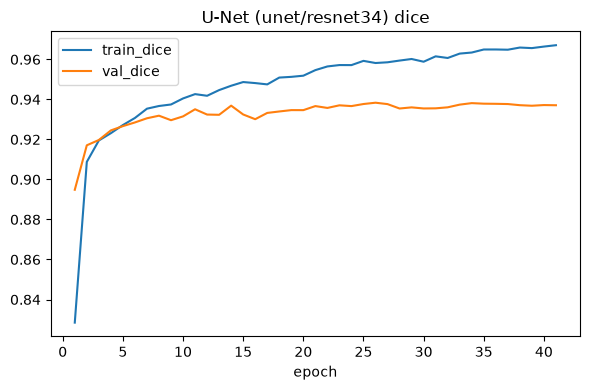

In [15]:
# TRAINING CELL — trains a real model. Run manually and deliberately, not via "Run All".
from unet.train import train_unet

train_unet(config)


2026-10-05 14:18:43 | INFO     | unet_evaluate | U-Net test-split metrics: {'dice': 0.9343565047438918, 'iou': 0.8789648390299541, 'precision': 0.9353817453156218, 'recall': 0.9370438029300828, 'specificity': 0.928480754866081}
{'dice': 0.9343565047438918, 'iou': 0.8789648390299541, 'precision': 0.9353817453156218, 'recall': 0.9370438029300828, 'specificity': 0.928480754866081}


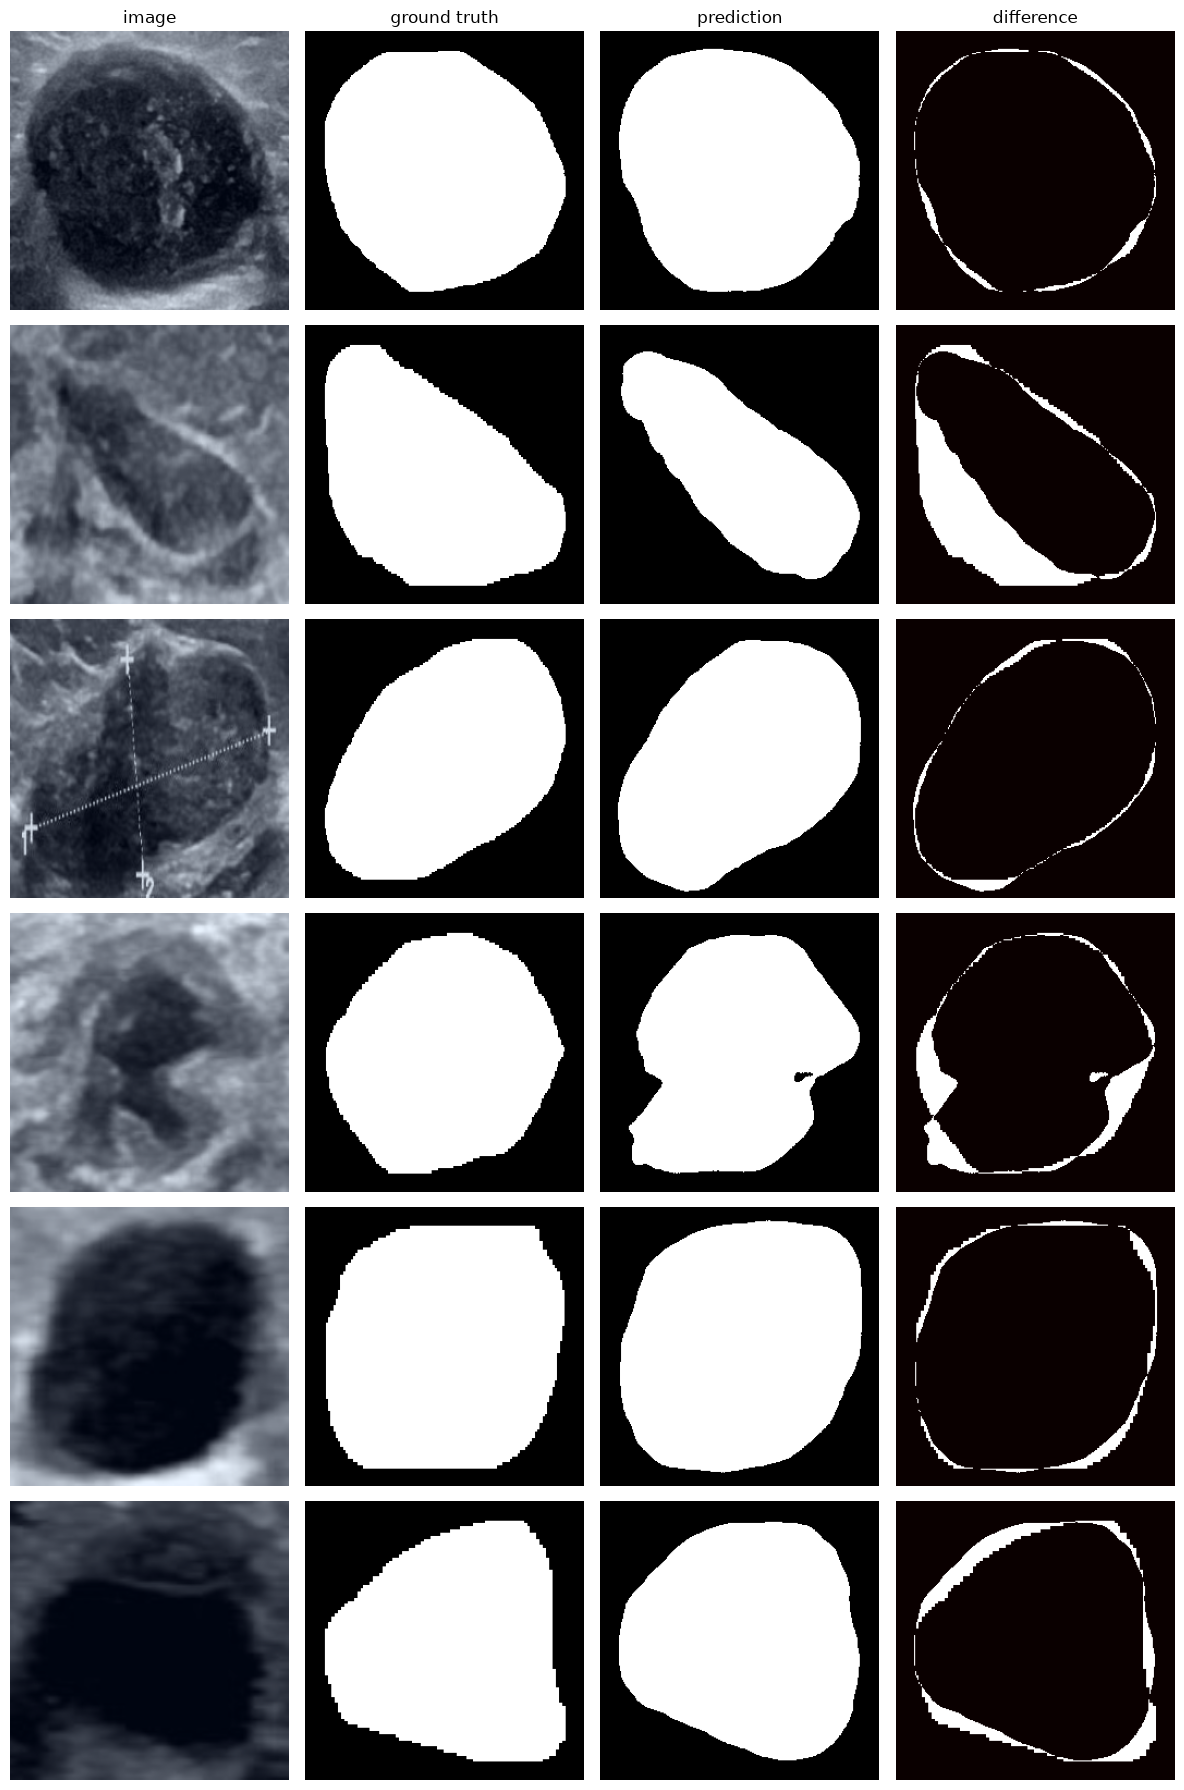

In [16]:
# Evaluation — run after the training cell above has produced a checkpoint.
from unet.evaluate import evaluate_unet

unet_checkpoint = REPO_ROOT / config["unet"]["checkpoint_dir"] / config["unet"]["checkpoint_name"]
unet_metrics = evaluate_unet(config, unet_checkpoint)
print(unet_metrics)


## Stage 4 — ResNet50 Classification

Two-phase transfer learning (linear-probe warmup, then full fine-tuning) on the masked tumor ROI,
using ground-truth lesion masks so this stage trains independently of Stage 3's own predictions.
**Trains a real model — run manually, not via "Run All".**

2026-10-05 14:18:50 | INFO     | resnet_train | Training ResNet50 on device=mps
2026-10-05 14:19:40 | INFO     | resnet_train | epoch 1/60 | train_loss=0.6515 train_acc=0.6585 | val_loss=0.6191 val_acc=0.6635
2026-10-05 14:19:41 | INFO     | resnet_train | New best val acc 0.6635 -> saved checkpoints/resnet/best_resnet.pth
2026-10-05 14:20:29 | INFO     | resnet_train | epoch 2/60 | train_loss=0.6043 train_acc=0.6853 | val_loss=0.6003 val_acc=0.6731
2026-10-05 14:20:29 | INFO     | resnet_train | New best val acc 0.6731 -> saved checkpoints/resnet/best_resnet.pth
2026-10-05 14:21:17 | INFO     | resnet_train | epoch 3/60 | train_loss=0.5860 train_acc=0.6875 | val_loss=0.5772 val_acc=0.6731
2026-10-05 14:22:05 | INFO     | resnet_train | epoch 4/60 | train_loss=0.5688 train_acc=0.6875 | val_loss=0.5564 val_acc=0.6923
2026-10-05 14:22:05 | INFO     | resnet_train | New best val acc 0.6923 -> saved checkpoints/resnet/best_resnet.pth
2026-10-05 14:22:53 | INFO     | resnet_train | epoch 5/

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

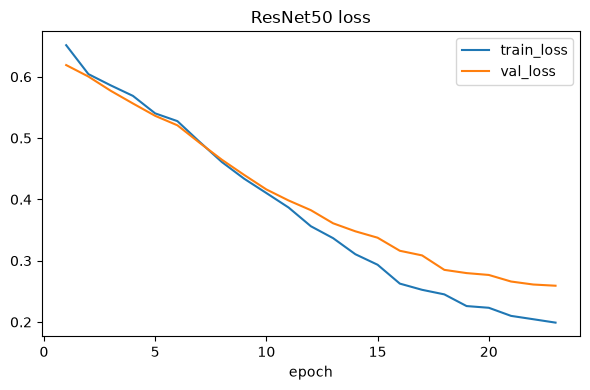

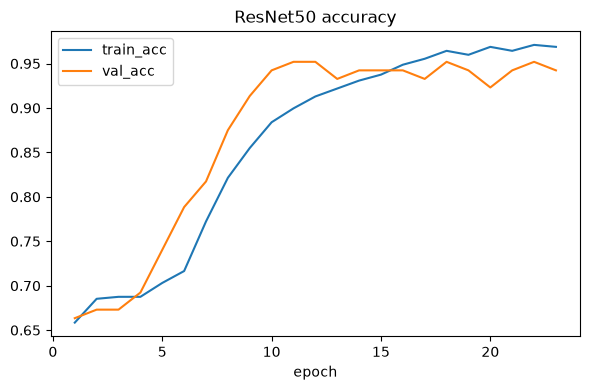

In [17]:
# TRAINING CELL — trains a real model. Run manually and deliberately, not via "Run All".
from resnet.train import train_resnet

train_resnet(config)


2026-10-05 14:40:26 | INFO     | resnet_evaluate | ResNet50 test-split metrics: {'accuracy': 0.91, 'precision': 0.8928571428571429, 'recall': 0.8064516129032258, 'f1': 0.847457627118644, 'cohen_kappa': 0.7838616714697406, 'mcc': 0.7859039982742418, 'roc_auc': 0.9789621318373072, 'pr_auc': 0.9620477200203464}
{'accuracy': 0.91, 'precision': 0.8928571428571429, 'recall': 0.8064516129032258, 'f1': 0.847457627118644, 'cohen_kappa': 0.7838616714697406, 'mcc': 0.7859039982742418, 'roc_auc': 0.9789621318373072, 'pr_auc': 0.9620477200203464}


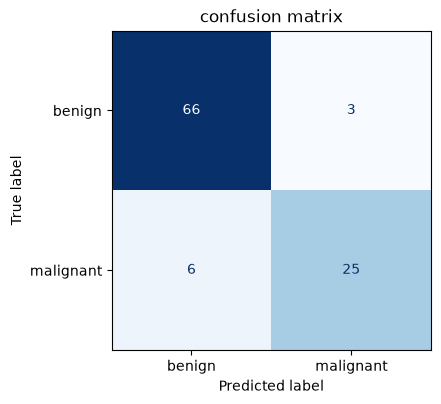

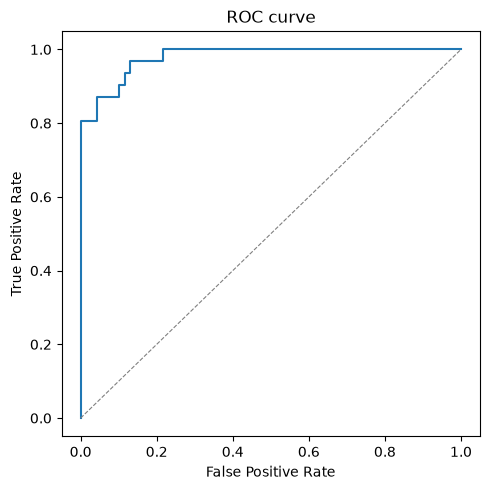

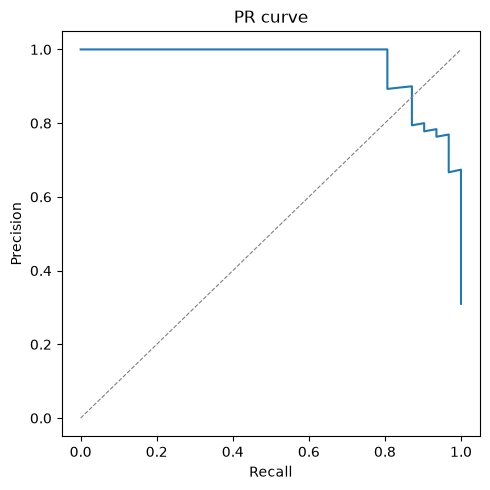

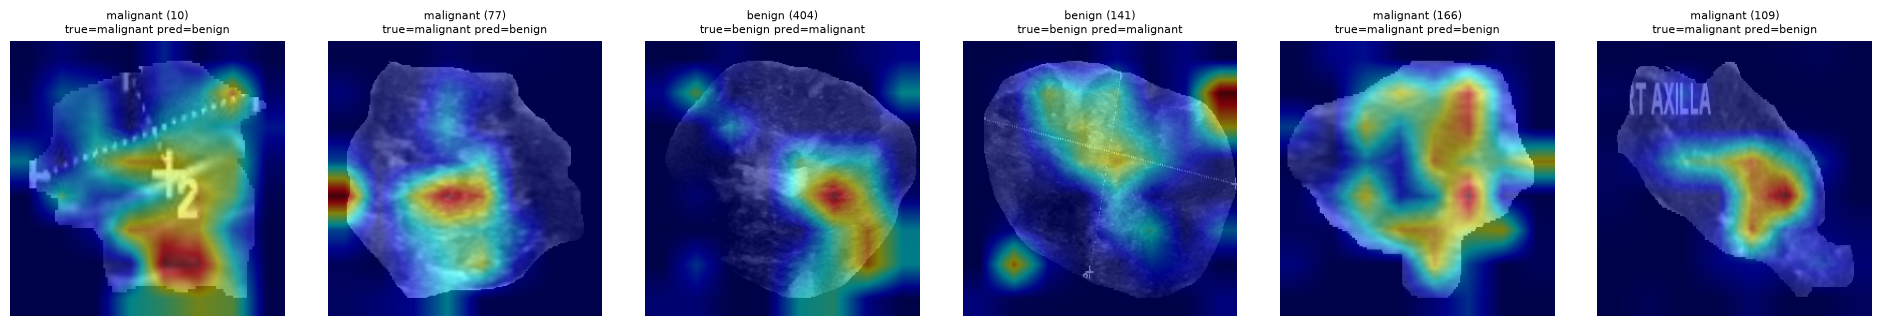

In [18]:
# Evaluation — run after the training cell above has produced a checkpoint.
from resnet.evaluate import evaluate_resnet

resnet_checkpoint = REPO_ROOT / config["resnet"]["checkpoint_dir"] / config["resnet"]["checkpoint_name"]
resnet_metrics = evaluate_resnet(config, resnet_checkpoint)
print(resnet_metrics)


## End-to-end cascade evaluation

Chains the *real* trained YOLO26n -> U-Net -> ResNet50 (not ground-truth-fed) over the test set, to
measure how much error propagates through the full cascade versus each stage's isolated evaluation
above. Requires all three checkpoints from Stages 2-4 to already exist.

In [19]:
from evaluation.cascade import evaluate_cascade

cascade_metrics = evaluate_cascade(config, split="test")
print(cascade_metrics)


2026-10-05 14:40:38 | INFO     | cascade_evaluate | End-to-end cascade metrics on test split: {'accuracy': 0.8636363636363636, 'precision': 0.7272727272727273, 'recall': 0.8888888888888888, 'f1': 0.8, 'cohen_kappa': 0.6981132075471699, 'mcc': 0.7062046123204374, 'roc_auc': 0.9222829386763813, 'pr_auc': 0.7938248001490961, 'num_detection_failures': 9, 'mean_detection_iou': 0.6696470124503907, 'mean_segmentation_dice': 0.8172134991214907}
{'accuracy': 0.8636363636363636, 'precision': 0.7272727272727273, 'recall': 0.8888888888888888, 'f1': 0.8, 'cohen_kappa': 0.6981132075471699, 'mcc': 0.7062046123204374, 'roc_auc': 0.9222829386763813, 'pr_auc': 0.7938248001490961, 'num_detection_failures': 9, 'mean_detection_iou': 0.6696470124503907, 'mean_segmentation_dice': 0.8172134991214907}


## Single-image inference demo

Runs the full cascade on one raw ultrasound image and visualizes every intermediate output
(detection, ROI, segmentation overlay, classification). Requires all three checkpoints to exist.

Predicted: benign (62.9%)


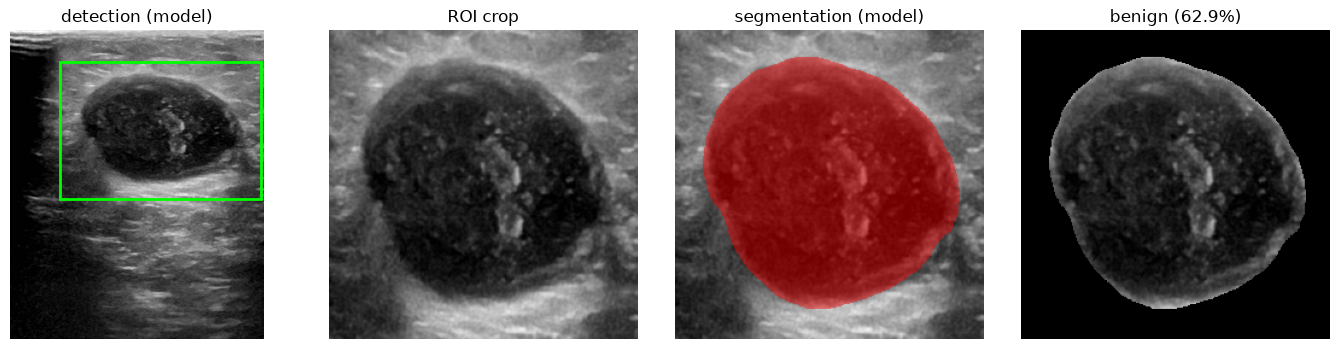

In [20]:
from inference.pipeline import build_pipeline
from inference.visualize import plot_case_result

test_rows = load_split(REPO_ROOT / config["paths"]["splits_dir"], "test")
sample_image_path = test_rows[0]["image_path"]

pipeline = build_pipeline(config)
case_result = pipeline.run(sample_image_path)
plot_case_result(case_result)
print(f"Predicted: {case_result.predicted_class} ({case_result.confidence:.1%})")


## Stage 5 — Clinician-in-the-loop demo

For interactive, physician-reviewed inference with accept/reject controls at every stage, run:

```bash
streamlit run app/app.py
```

The app reuses `inference/pipeline.py` and `preprocessing/roi_utils.py` — the same modules used above —
so its behavior matches this notebook's cascade exactly, with physician review layered on top.